# 2023-04-01 Outlier Analysis: Wet Snow & Backscatter Drop

The 2023-04-01 cycle stands out from all other high-danger dates:
- Scene-wide backscatter **drop** (d_empirical mean ~ -1.0) vs. winter dates near 0 or positive
- Mahalanobis distance picks up debris *better* than empirical — likely because the ML model
  absorbs the systematic wet-snow drop into its per-pixel baseline, leaving only relative
  anomalies (debris deposits drop less than surrounding wet snow)

Hypothesis: **wet snow** at this late-season date causes widespread liquid water in the
snowpack, which strongly absorbs C-band SAR signal uniformly across the scene.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

RUNS_DIR = Path('/Users/zmhoppinen/Documents/sarvalanche/local/issw/high_danger_output/sarvalanche_runs')
SNOTEL_CSV = Path('/Users/zmhoppinen/Documents/sarvalanche/local/issw/snotels/490_STAND_WATERYEAR=2023.csv')

## 1. SNOTEL Weather Context (Galena Summit, WY2023)

Load temperature and SWE from the nearby SNOTEL station to show warming conditions
around the 2023-04-01 avalanche date.

In [2]:
# Parse the SNOTEL CSV (skip header lines)
snotel = pd.read_csv(SNOTEL_CSV, skiprows=6, skipinitialspace=True)
snotel.columns = snotel.columns.str.strip()
snotel['Date'] = pd.to_datetime(snotel['Date'])

# Clean up column names
col_map = {}
for c in snotel.columns:
    if 'WTEQ' in c:
        col_map[c] = 'SWE_in'
    elif 'TMAX' in c:
        col_map[c] = 'Tmax_C'
    elif 'TMIN' in c:
        col_map[c] = 'Tmin_C'
    elif 'TAVG' in c:
        col_map[c] = 'Tavg_C'
    elif 'TOBS' in c:
        col_map[c] = 'Tobs_C'
    elif 'SNWD' in c:
        col_map[c] = 'SnowDepth_in'
    elif 'PREC' in c:
        col_map[c] = 'Precip_in'
snotel = snotel.rename(columns=col_map)

# Replace -99.9 sentinel with NaN
for c in ['Tmax_C', 'Tmin_C', 'Tavg_C', 'Tobs_C']:
    if c in snotel.columns:
        snotel[c] = snotel[c].replace(-99.9, np.nan)

snotel = snotel.set_index('Date')
print(f'SNOTEL records: {snotel.index[0].date()} to {snotel.index[-1].date()}')
snotel.head()

SNOTEL records: 2022-10-01 to 2023-09-30


,Site Id,Time,SWE_in,Precip_in,Tobs_C,Tmax_C,Tmin_C,Tavg_C,SnowDepth_in,Unnamed: 10
Date,,,,,,,,,,
2022-10-01,490,NaN,0.0,0.0,0.1,8.0,-1.8,0.7,0.0,NaN
2022-10-02,490,NaN,0.0,0.0,0.6,8.7,-2.1,2.9,0.0,NaN
2022-10-03,490,NaN,0.0,0.0,1.0,10.4,-0.9,3.8,0.0,NaN
2022-10-04,490,NaN,0.0,0.0,2.8,14.3,0.3,6.0,0.0,NaN
2022-10-05,490,NaN,0.0,0.0,3.4,16.5,2.6,7.9,0.0,NaN


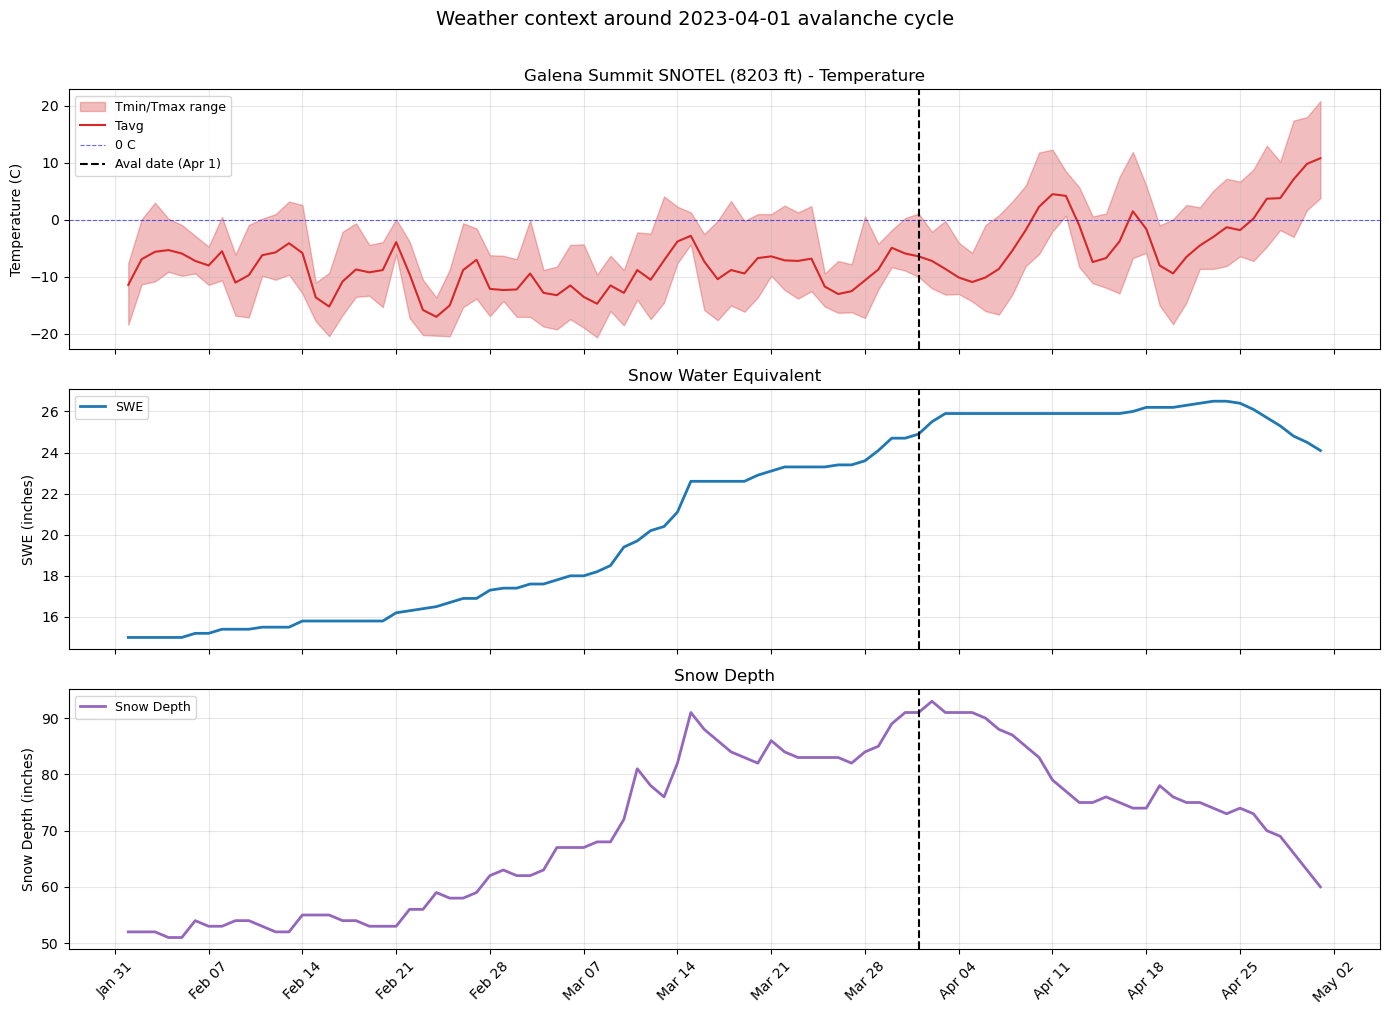

In [3]:
# Focus on Feb-Apr 2023 window
window = snotel.loc['2023-02-01':'2023-05-01']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

avl_date = pd.Timestamp('2023-04-01')

# -- Temperature --
ax = axes[0]
ax.fill_between(window.index, window['Tmin_C'], window['Tmax_C'],
                alpha=0.3, color='tab:red', label='Tmin/Tmax range')
ax.plot(window.index, window['Tavg_C'], 'tab:red', lw=1.5, label='Tavg')
ax.axhline(0, color='blue', ls='--', lw=0.8, alpha=0.6, label='0 C')
ax.axvline(avl_date, color='black', ls='--', lw=1.5, label='Aval date (Apr 1)')
ax.set_ylabel('Temperature (C)')
ax.set_title('Galena Summit SNOTEL (8203 ft) - Temperature', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# -- SWE --
ax = axes[1]
ax.plot(window.index, window['SWE_in'], 'tab:blue', lw=2, label='SWE')
ax.axvline(avl_date, color='black', ls='--', lw=1.5)
ax.set_ylabel('SWE (inches)')
ax.set_title('Snow Water Equivalent', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# -- Snow Depth --
ax = axes[2]
ax.plot(window.index, window['SnowDepth_in'], 'tab:purple', lw=2, label='Snow Depth')
ax.axvline(avl_date, color='black', ls='--', lw=1.5)
ax.set_ylabel('Snow Depth (inches)')
ax.set_title('Snow Depth', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)

fig.suptitle('Weather context around 2023-04-01 avalanche cycle', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Backscatter Distance Comparison Across All High-Danger Dates

Compare the empirical distance (`d_empirical`) and Mahalanobis distance distributions
across all Banner Summit cycles. 2023-04-01 should be the clear outlier in empirical
distances but look normal in Mahalanobis space.

In [4]:
# Load stats from all Banner Summit .nc files
nc_files = sorted(RUNS_DIR.glob('Banner_Summit_*.nc'))

stats = []
dist_samples = {}  # date -> (d_emp sample, d_mah sample) for histograms

for nc_path in nc_files:
    date_str = nc_path.stem.replace('Banner_Summit_', '')
    ds = xr.open_dataset(nc_path)

    d_emp = ds['d_empirical'].values.ravel()
    d_emp = d_emp[~np.isnan(d_emp)]

    d_mah = ds['distance_mahalanobis'].values.ravel()
    d_mah = d_mah[~np.isnan(d_mah)]

    d_comb = ds['combined_distance'].values.ravel()
    d_comb = d_comb[~np.isnan(d_comb)]

    stats.append({
        'date': date_str,
        'd_emp_mean': d_emp.mean(),
        'd_emp_median': np.median(d_emp),
        'd_emp_std': d_emp.std(),
        'd_emp_p10': np.percentile(d_emp, 10),
        'd_emp_p90': np.percentile(d_emp, 90),
        'd_mah_mean': d_mah.mean(),
        'd_mah_median': np.median(d_mah),
        'd_mah_std': d_mah.std(),
        'd_comb_mean': d_comb.mean(),
        'd_comb_std': d_comb.std(),
    })

    # Subsample for histograms
    rng = np.random.default_rng(42)
    n_sample = min(100_000, len(d_emp))
    dist_samples[date_str] = (
        rng.choice(d_emp, n_sample, replace=False),
        rng.choice(d_mah, n_sample, replace=False),
    )
    ds.close()

stats_df = pd.DataFrame(stats).set_index('date')
stats_df.style.format('{:.3f}').bar(
    subset=['d_emp_mean'], color=['#d65f5f', '#5fba7d'], align='zero'
)

,d_emp_mean,d_emp_median,d_emp_std,d_emp_p10,d_emp_p90,d_mah_mean,d_mah_median,d_mah_std,d_comb_mean,d_comb_std
date,,,,,,,,,,
2022-12-12,0.195,0.237,0.529,-0.431,0.792,0.162,0.149,0.074,1.249,0.615
2023-03-13,-0.457,-0.326,0.863,-1.445,0.405,0.118,0.116,0.087,0.518,1.337
2023-04-01,-1.036,-0.928,0.858,-2.235,-0.014,0.156,0.143,0.079,1.155,0.748
2024-01-12,0.267,0.289,0.487,-0.346,0.860,0.137,0.128,0.075,0.968,0.804
2024-02-05,0.517,0.511,0.594,-0.203,1.235,0.174,0.163,0.081,1.320,0.681
2024-02-29,0.077,0.119,0.568,-0.659,0.747,0.199,0.184,0.089,1.512,0.609
2024-12-29,0.750,0.741,0.590,0.001,1.508,0.205,0.193,0.087,1.550,0.625
2025-02-04,0.120,0.115,0.467,-0.435,0.686,0.147,0.133,0.076,1.098,0.694


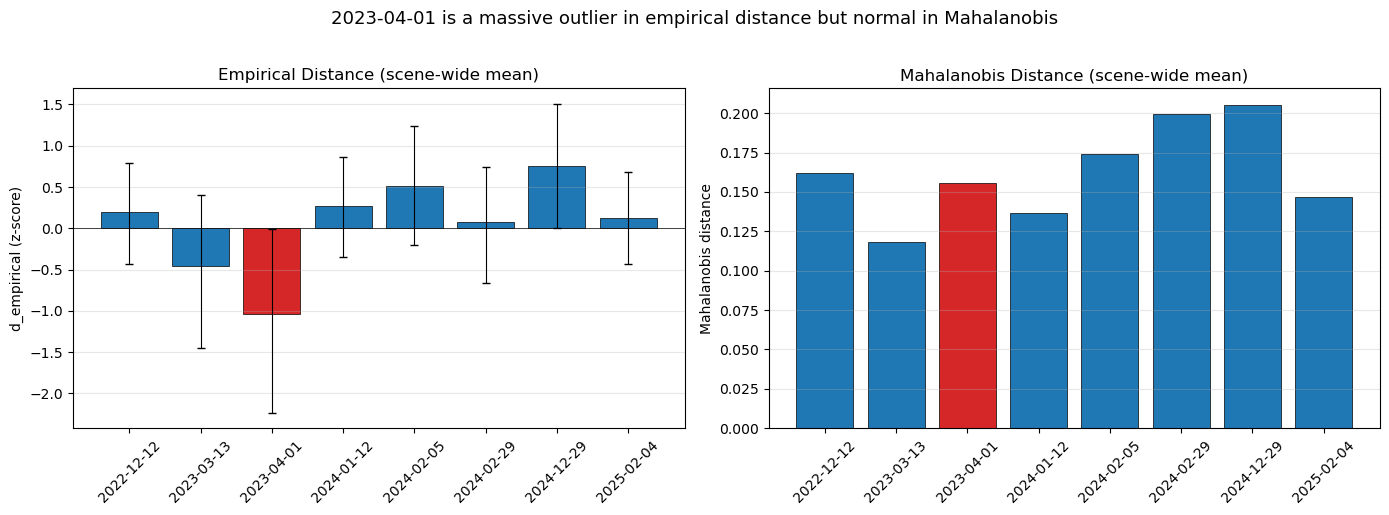

In [5]:
# Bar chart: mean d_empirical per date
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dates = stats_df.index.tolist()
colors = ['tab:red' if '2023-04-01' in d else 'tab:blue' for d in dates]

ax = axes[0]
bars = ax.bar(dates, stats_df['d_emp_mean'], color=colors, edgecolor='black', lw=0.5)
ax.errorbar(dates, stats_df['d_emp_mean'],
            yerr=[stats_df['d_emp_mean'] - stats_df['d_emp_p10'],
                  stats_df['d_emp_p90'] - stats_df['d_emp_mean']],
            fmt='none', color='black', capsize=3, lw=0.8)
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_ylabel('d_empirical (z-score)')
ax.set_title('Empirical Distance (scene-wide mean)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.bar(dates, stats_df['d_mah_mean'], color=colors, edgecolor='black', lw=0.5)
ax.set_ylabel('Mahalanobis distance')
ax.set_title('Mahalanobis Distance (scene-wide mean)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('2023-04-01 is a massive outlier in empirical distance but normal in Mahalanobis',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

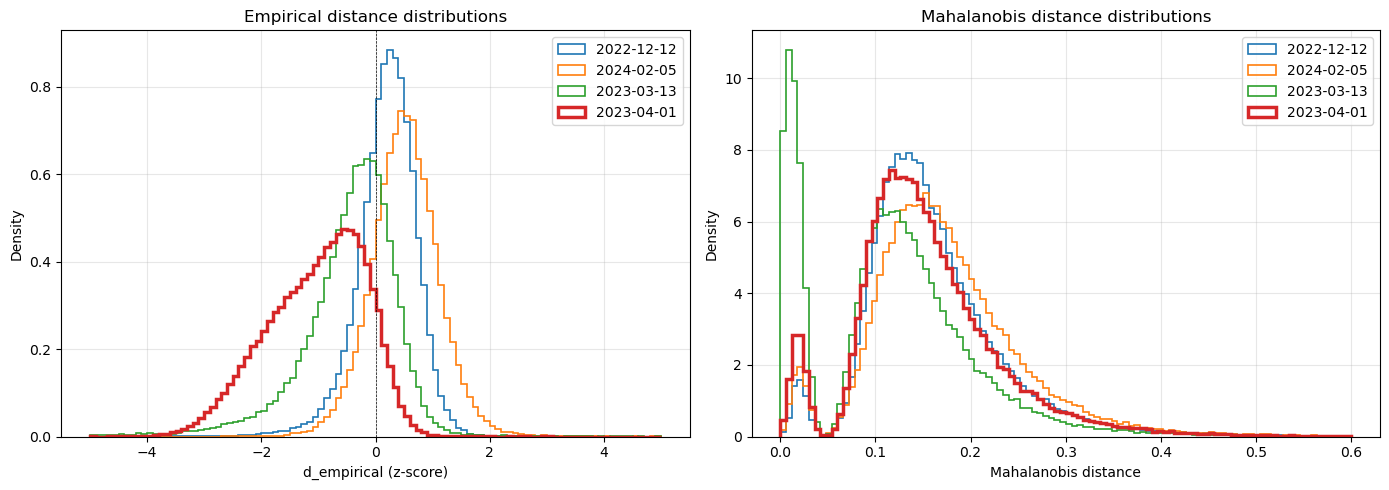

In [6]:
# Histograms: d_empirical distributions for a few representative dates
compare_dates = ['2022-12-12', '2024-02-05', '2023-03-13', '2023-04-01']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for d in compare_dates:
    emp, _ = dist_samples[d]
    lw = 2.5 if d == '2023-04-01' else 1.2
    ax.hist(emp, bins=100, range=(-5, 5), density=True, histtype='step',
            lw=lw, label=d)
ax.axvline(0, color='black', ls='--', lw=0.5)
ax.set_xlabel('d_empirical (z-score)')
ax.set_ylabel('Density')
ax.set_title('Empirical distance distributions')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for d in compare_dates:
    _, mah = dist_samples[d]
    lw = 2.5 if d == '2023-04-01' else 1.2
    ax.hist(mah, bins=100, range=(0, 0.6), density=True, histtype='step',
            lw=lw, label=d)
ax.set_xlabel('Mahalanobis distance')
ax.set_ylabel('Density')
ax.set_title('Mahalanobis distance distributions')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Per-Orbit Breakdown

All three Sentinel-1 orbits show the same systematic drop on 2023-04-01,
confirming this is a scene-wide physical phenomenon (wet snow), not an orbit-specific
processing artifact.

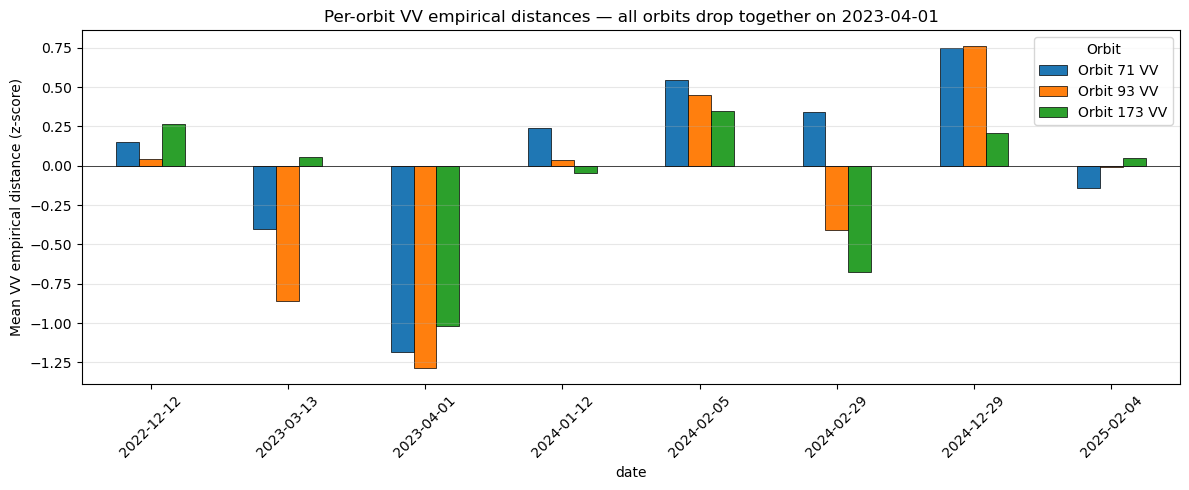

In [7]:
# Per-orbit empirical VV distances across dates
orbit_vars = ['d_71_VV_empirical', 'd_93_VV_empirical', 'd_173_VV_empirical']
orbit_labels = ['Orbit 71 VV', 'Orbit 93 VV', 'Orbit 173 VV']

orbit_stats = []
for nc_path in nc_files:
    date_str = nc_path.stem.replace('Banner_Summit_', '')
    ds = xr.open_dataset(nc_path)
    row = {'date': date_str}
    for var, label in zip(orbit_vars, orbit_labels):
        if var in ds:
            vals = ds[var].values.ravel()
            vals = vals[~np.isnan(vals)]
            row[label] = vals.mean() if len(vals) > 0 else np.nan
        else:
            row[label] = np.nan
    orbit_stats.append(row)
    ds.close()

orbit_df = pd.DataFrame(orbit_stats).set_index('date')

fig, ax = plt.subplots(figsize=(12, 5))
orbit_df.plot(kind='bar', ax=ax, edgecolor='black', lw=0.5)
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_ylabel('Mean VV empirical distance (z-score)')
ax.set_title('Per-orbit VV empirical distances — all orbits drop together on 2023-04-01')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(title='Orbit')
plt.tight_layout()
plt.show()

## 4. SNOTEL + SAR Timeline

Overlay the SAR acquisition dates on the SNOTEL temperature record to show that
the 2023-04-01 acquisitions straddle a warm period where Tmax consistently exceeds 0 C,
implying liquid water in the snowpack.

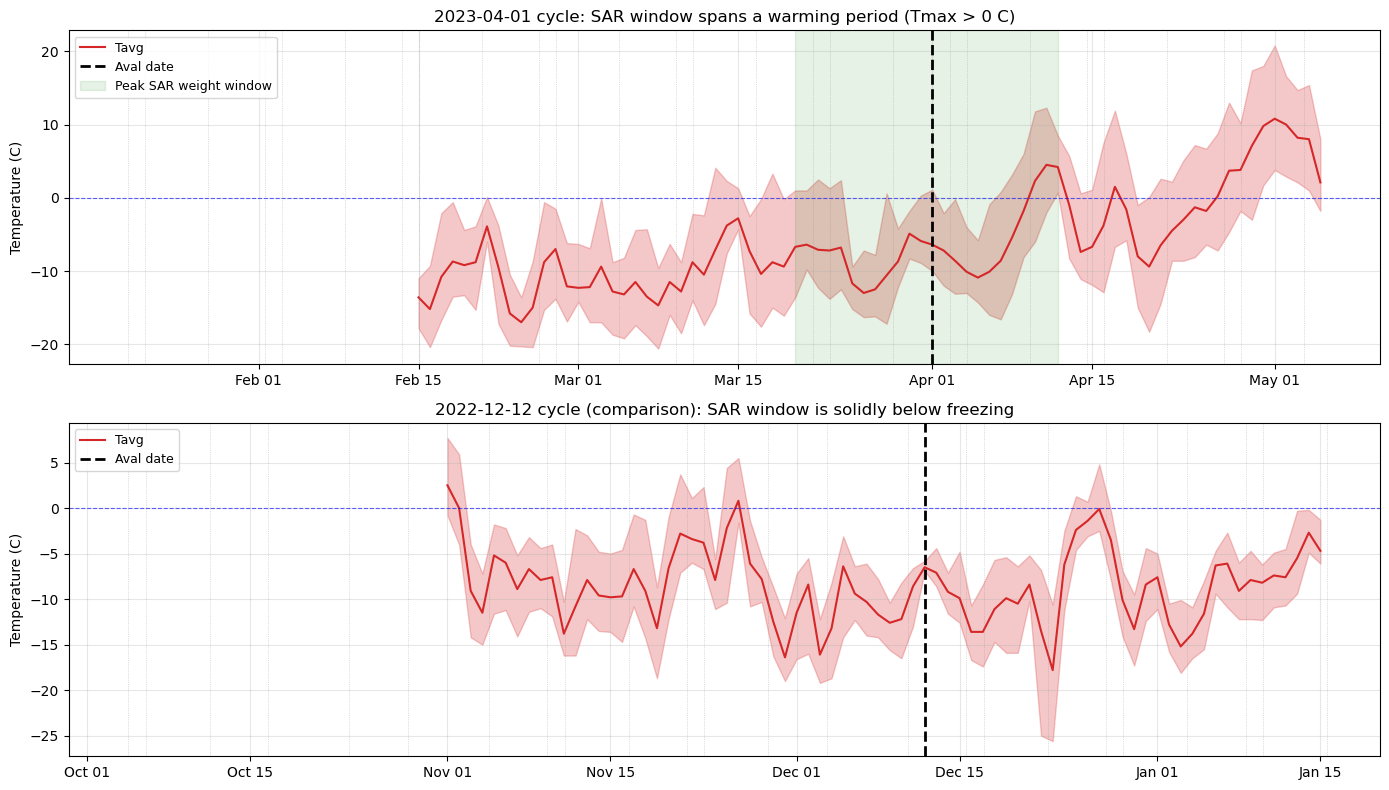

In [8]:
# Load the SAR acquisition times for 2023-04-01 cycle
ds_apr = xr.open_dataset(RUNS_DIR / 'Banner_Summit_2023-04-01.nc')
sar_times = pd.DatetimeIndex(ds_apr['w_temporal'].time.values)
sar_weights = ds_apr['w_temporal'].values
ds_apr.close()

# Also load a winter cycle for comparison
ds_dec = xr.open_dataset(RUNS_DIR / 'Banner_Summit_2022-12-12.nc')
sar_times_dec = pd.DatetimeIndex(ds_dec['w_temporal'].time.values)
ds_dec.close()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# -- Apr 2023 --
ax = axes[0]
win = snotel.loc['2023-02-15':'2023-05-05']
ax.fill_between(win.index, win['Tmin_C'], win['Tmax_C'],
                alpha=0.25, color='tab:red')
ax.plot(win.index, win['Tavg_C'], 'tab:red', lw=1.5, label='Tavg')
ax.axhline(0, color='blue', ls='--', lw=0.8, alpha=0.6)
# Mark SAR acquisitions
for t in sar_times:
    ax.axvline(t, color='gray', ls=':', lw=0.5, alpha=0.5)
ax.axvline(pd.Timestamp('2023-04-01'), color='black', ls='--', lw=2, label='Aval date')
# Shade the high-weight SAR window (approx +/- 12 days)
ax.axvspan(pd.Timestamp('2023-03-20'), pd.Timestamp('2023-04-12'),
           alpha=0.1, color='green', label='Peak SAR weight window')
ax.set_ylabel('Temperature (C)')
ax.set_title('2023-04-01 cycle: SAR window spans a warming period (Tmax > 0 C)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# -- Dec 2022 (for comparison) --
ax = axes[1]
win = snotel.loc['2022-11-01':'2023-01-15']
ax.fill_between(win.index, win['Tmin_C'], win['Tmax_C'],
                alpha=0.25, color='tab:red')
ax.plot(win.index, win['Tavg_C'], 'tab:red', lw=1.5, label='Tavg')
ax.axhline(0, color='blue', ls='--', lw=0.8, alpha=0.6)
for t in sar_times_dec:
    ax.axvline(t, color='gray', ls=':', lw=0.5, alpha=0.5)
ax.axvline(pd.Timestamp('2022-12-12'), color='black', ls='--', lw=2, label='Aval date')
ax.set_ylabel('Temperature (C)')
ax.set_title('2022-12-12 cycle (comparison): SAR window is solidly below freezing', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()

## 5. Why Mahalanobis Works Better Here

The Mahalanobis model learns per-pixel expected backscatter and variance. When the
entire scene drops due to wet snow, the model's predicted mean shifts accordingly (the
`d_*_ml` values stay centered near ~0.5-0.7, same as other dates). Only *relative*
anomalies — debris paths that drop less than surrounding wet snow — stand out.

The raw empirical ECDF-based approach compares against a fixed distribution, so the
scene-wide drop pushes everything negative, drowning out the real debris signal.

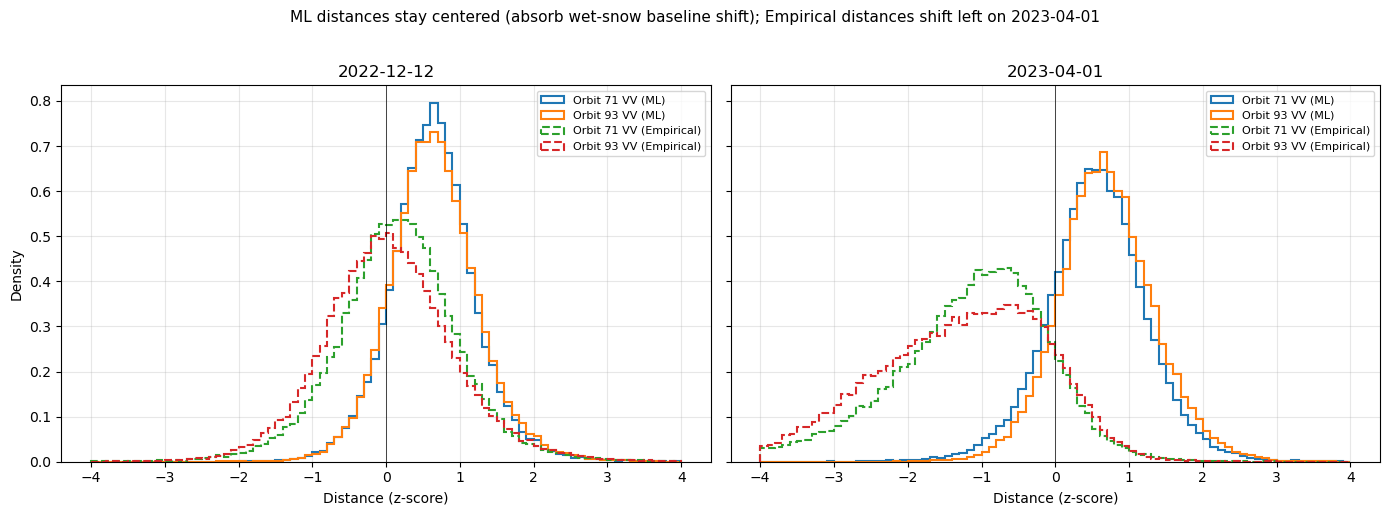

In [9]:
# ML distances (Mahalanobis components) vs empirical for 2023-04-01 and a winter date
compare = {
    '2022-12-12': RUNS_DIR / 'Banner_Summit_2022-12-12.nc',
    '2023-04-01': RUNS_DIR / 'Banner_Summit_2023-04-01.nc',
}

ml_vars = ['d_71_VV_ml', 'd_93_VV_ml', 'd_71_VV_empirical', 'd_93_VV_empirical']
ml_labels = ['Orbit 71 VV (ML)', 'Orbit 93 VV (ML)',
             'Orbit 71 VV (Empirical)', 'Orbit 93 VV (Empirical)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (date_str, nc_path) in zip(axes, compare.items()):
    ds = xr.open_dataset(nc_path)
    rng = np.random.default_rng(42)
    for var, label in zip(ml_vars, ml_labels):
        if var in ds:
            vals = ds[var].values.ravel()
            vals = vals[~np.isnan(vals)]
            sample = rng.choice(vals, min(50_000, len(vals)), replace=False)
            ls = '-' if 'ml' in var.lower() else '--'
            ax.hist(sample, bins=80, range=(-4, 4), density=True,
                    histtype='step', lw=1.5, ls=ls, label=label)
    ax.axvline(0, color='black', ls='-', lw=0.5)
    ax.set_xlabel('Distance (z-score)')
    ax.set_title(date_str, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ds.close()

axes[0].set_ylabel('Density')
fig.suptitle(
    'ML distances stay centered (absorb wet-snow baseline shift); '
    'Empirical distances shift left on 2023-04-01',
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

## 6. Summary

| Metric | Winter dates (typical) | 2023-04-01 |
|--------|----------------------|------------|
| d_empirical mean | +0.2 to +0.5 | **-1.04** |
| d_empirical p90 | +0.8 to +1.2 | **-0.01** |
| Mahalanobis mean | 0.13 - 0.17 | **0.16** (normal) |
| SNOTEL Tmax | well below 0 C | **reaching +1 C** |
| Season | Dec - Feb | **April** (wet snow) |

**Conclusion**: The 2023-04-01 cycle is a wet-snow event. Liquid water in the snowpack
causes a scene-wide C-band backscatter drop that overwhelms the empirical detector.
The Mahalanobis approach handles this because its per-pixel learned baseline absorbs
the systematic shift — debris deposits that drop *less* than the wet background stand
out as relative anomalies.

**Implication for the pipeline**: Late-season / wet-snow cycles need either:
1. A wet-snow flag to switch to Mahalanobis-only detection, or
2. Scene-level normalization of the empirical distances before thresholding